# Task
Load the 'data/raw/paysim/PS_20174392719_1491204439457_log.csv' dataset into a pandas DataFrame, then display its shape, data types, memory usage, the first 5 rows, and descriptive statistics.

## Data Loading and Overview

### Subtask:
Load the 'data/raw/paysim/PS_20174392719_1491204439457_log.csv' dataset into a pandas DataFrame. Display its shape, data types, and memory usage. Show the first 5 rows and generate descriptive statistics using `.describe()`.


**Reasoning**:
To begin the data loading and overview subtask, I will import the pandas library, load the specified CSV file into a DataFrame, and then display its shape, data types, memory usage, the first 5 rows, and descriptive statistics.



In [9]:
import pandas as pd

# Load the dataset using the corrected path
df = pd.read_csv('drive/MyDrive/Fraud-detection/Data/raw/PS_20174392719_1491204439457_log.csv')

print("DataFrame Shape:")
print(df.shape)
print("\nDataFrame Info (Data Types and Non-Null Counts):\n")
df.info()
print("\nDataFrame Info (Memory Usage - Deep):\n")
df.info(memory_usage='deep')
print("\nFirst 5 Rows of the DataFrame:\n")
print(df.head())
print("\nDescriptive Statistics of the DataFrame:\n")
print(df.describe())

DataFrame Shape:
(6362620, 11)

DataFrame Info (Data Types and Non-Null Counts):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB

DataFrame Info (Memory Usage - Deep):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   new

## Class Imbalance Analysis

### Subtask:
Calculate and print the count and percentage of fraudulent versus legitimate transactions. Create a bar chart to visualize this class distribution. Analyze and display the fraud rate for each transaction type, focusing on 'TRANSFER' and 'CASH_OUT' where fraud occurs.


**Reasoning**:
I will calculate the counts and percentages of fraudulent and legitimate transactions, then visualize this distribution with a bar chart to understand the class imbalance. After that, I will calculate and display the fraud rate for each transaction type to identify types with significant fraud.




Counts of fraudulent vs. legitimate transactions:
 isFraud
0    6354407
1       8213
Name: count, dtype: int64

Percentages of fraudulent vs. legitimate transactions:
 isFraud
0    99.870918
1     0.129082
Name: count, dtype: float64


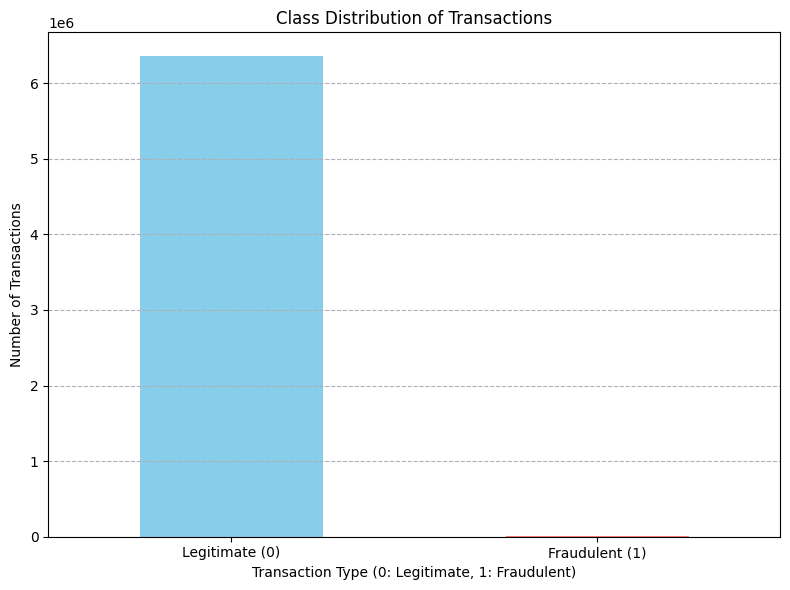


Fraud rate by transaction type (%):
 type
CASH_IN     0.000000
CASH_OUT    0.183955
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.768799
Name: isFraud, dtype: float64

Fraud rate for 'TRANSFER': 0.7687991758442811 %
Fraud rate for 'CASH_OUT': 0.18395530726256984 %


In [10]:
import matplotlib.pyplot as plt

# 1. Calculate the count of fraudulent and legitimate transactions
fraud_counts = df['isFraud'].value_counts()

# 2. Print the fraud_counts
print("\nCounts of fraudulent vs. legitimate transactions:\n", fraud_counts)

# 3. Calculate the percentage of fraudulent and legitimate transactions
fraud_percentages = (fraud_counts / len(df)) * 100

# 4. Print the fraud_percentages
print("\nPercentages of fraudulent vs. legitimate transactions:\n", fraud_percentages)

# 5. Create a bar chart for class distribution
plt.figure(figsize=(8, 6))
fraud_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Distribution of Transactions')
plt.xlabel('Transaction Type (0: Legitimate, 1: Fraudulent)')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['Legitimate (0)', 'Fraudulent (1)'], rotation=0)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()

# 6. Display the bar chart
plt.show()

# 7. Calculate the fraud rate for each transaction type
fraud_rate_by_type = df.groupby('type')['isFraud'].mean() * 100

# 8. Print the fraud rates
print("\nFraud rate by transaction type (%):\n", fraud_rate_by_type)

# Focus on 'TRANSFER' and 'CASH_OUT' if they are the only types with fraud (optional, based on common knowledge of this dataset)
print("\nFraud rate for 'TRANSFER':", fraud_rate_by_type.get('TRANSFER', 0), "%")
print("Fraud rate for 'CASH_OUT':", fraud_rate_by_type.get('CASH_OUT', 0), "%")

## Transaction Patterns

### Subtask:
Generate histograms (on a logarithmic scale) for transaction amounts, separately for fraudulent and non-fraudulent transactions. Create box plots to show the distribution of transaction amounts by 'type'. Visualize the distribution of fraudulent versus legitimate amounts using violin plots. Ensure all plots have appropriate titles and legends.


**Reasoning**:
I will first filter the DataFrame into fraudulent and legitimate transactions. Then, I will generate histograms for transaction amounts on a logarithmic scale for both types of transactions, ensuring clear titles and labels. This addresses the first part of the subtask regarding transaction amount distributions.



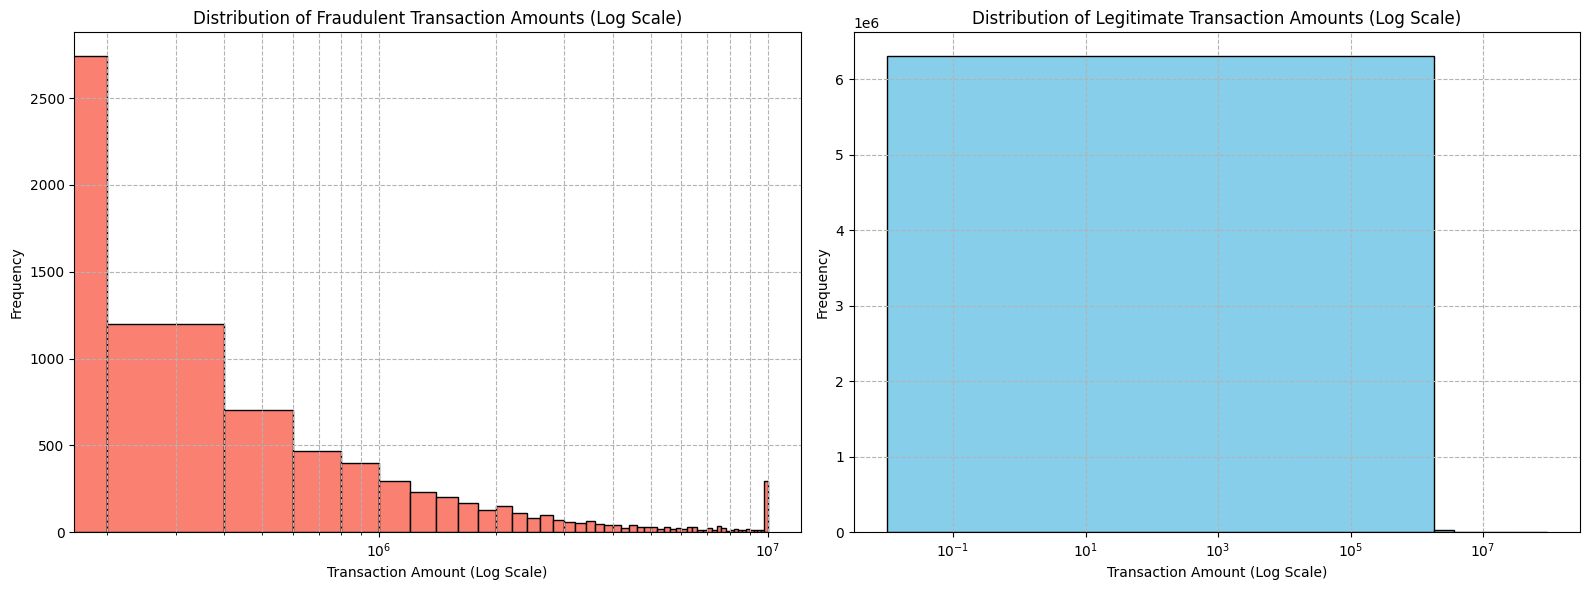

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter the DataFrame into fraudulent and legitimate transactions
df_fraud = df[df['isFraud'] == 1]
df_legit = df[df['isFraud'] == 0]

# 2. Create a figure with two subplots side-by-side for histograms
plt.figure(figsize=(16, 6))

# 3. Plot histogram for fraudulent transactions
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.hist(df_fraud['amount'], bins=50, color='salmon', edgecolor='black')
plt.xscale('log')
plt.title('Distribution of Fraudulent Transaction Amounts (Log Scale)')
plt.xlabel('Transaction Amount (Log Scale)')
plt.ylabel('Frequency')
plt.grid(True, which="both", ls="--", c='0.7')

# 4. Plot histogram for legitimate transactions
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.hist(df_legit['amount'], bins=50, color='skyblue', edgecolor='black')
plt.xscale('log')
plt.title('Distribution of Legitimate Transaction Amounts (Log Scale)')
plt.xlabel('Transaction Amount (Log Scale)')
plt.ylabel('Frequency')
plt.grid(True, which="both", ls="--", c='0.7')

# 5. Adjust the layout and display the histograms
plt.tight_layout()
plt.show()


**Reasoning**:
Now I will create a box plot to show the distribution of transaction amounts by 'type' and a violin plot to visualize the distribution of fraudulent versus legitimate amounts, as per the subtask requirements.



/tmp/ipykernel_208/696610980.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='amount', data=df, palette='viridis')


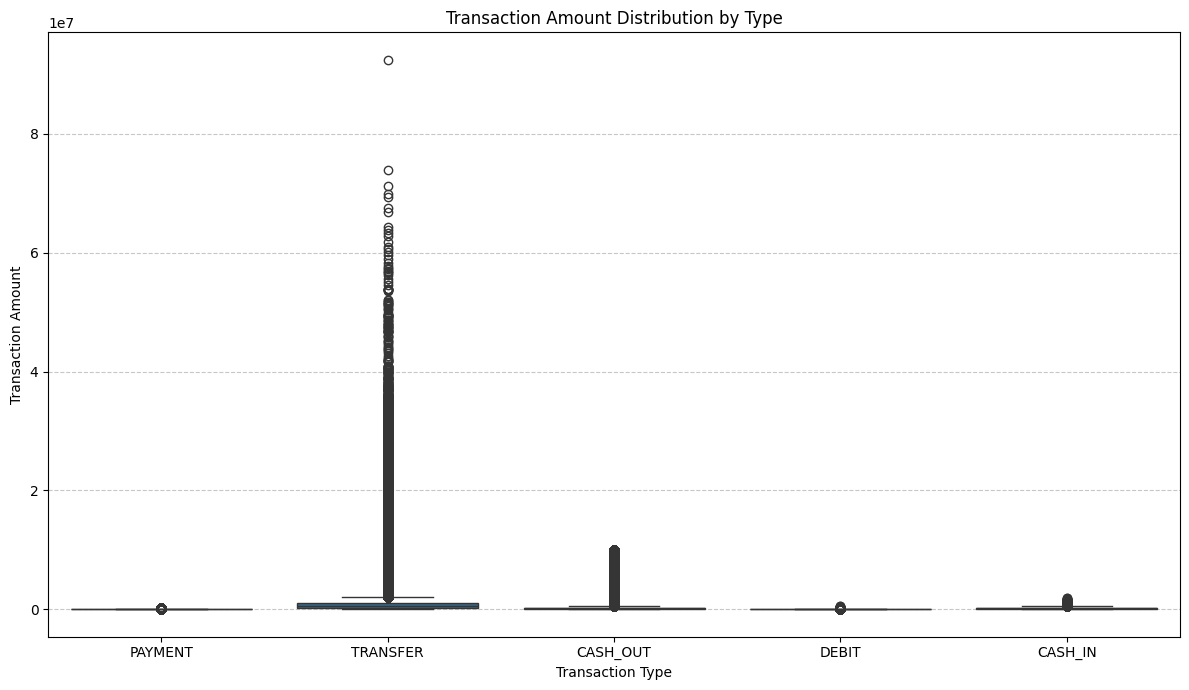

/tmp/ipykernel_208/696610980.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='isFraud', y='amount', data=df, palette='muted')


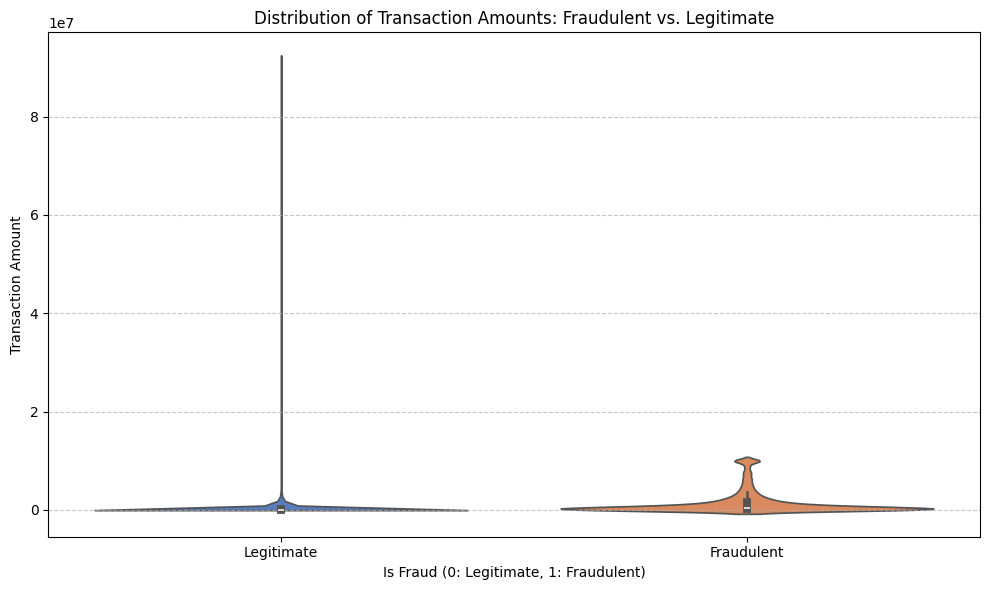

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 6. Create a box plot of the 'amount' column, grouped by the 'type' column
plt.figure(figsize=(12, 7))
sns.boxplot(x='type', y='amount', data=df, palette='viridis')
plt.title('Transaction Amount Distribution by Type')
plt.xlabel('Transaction Type')
plt.ylabel('Transaction Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 7. Create a violin plot to visualize the distribution of 'amount' split by 'isFraud'
plt.figure(figsize=(10, 6))
sns.violinplot(x='isFraud', y='amount', data=df, palette='muted')
plt.title('Distribution of Transaction Amounts: Fraudulent vs. Legitimate')
plt.xlabel('Is Fraud (0: Legitimate, 1: Fraudulent)')
plt.ylabel('Transaction Amount')
plt.xticks(ticks=[0, 1], labels=['Legitimate', 'Fraudulent'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reasoning**:
To resolve the `FutureWarning` regarding `palette` usage in `seaborn` plots, I will explicitly set the `hue` parameter to the same variable as `x` and add `legend=False` for both the box plot and violin plot.



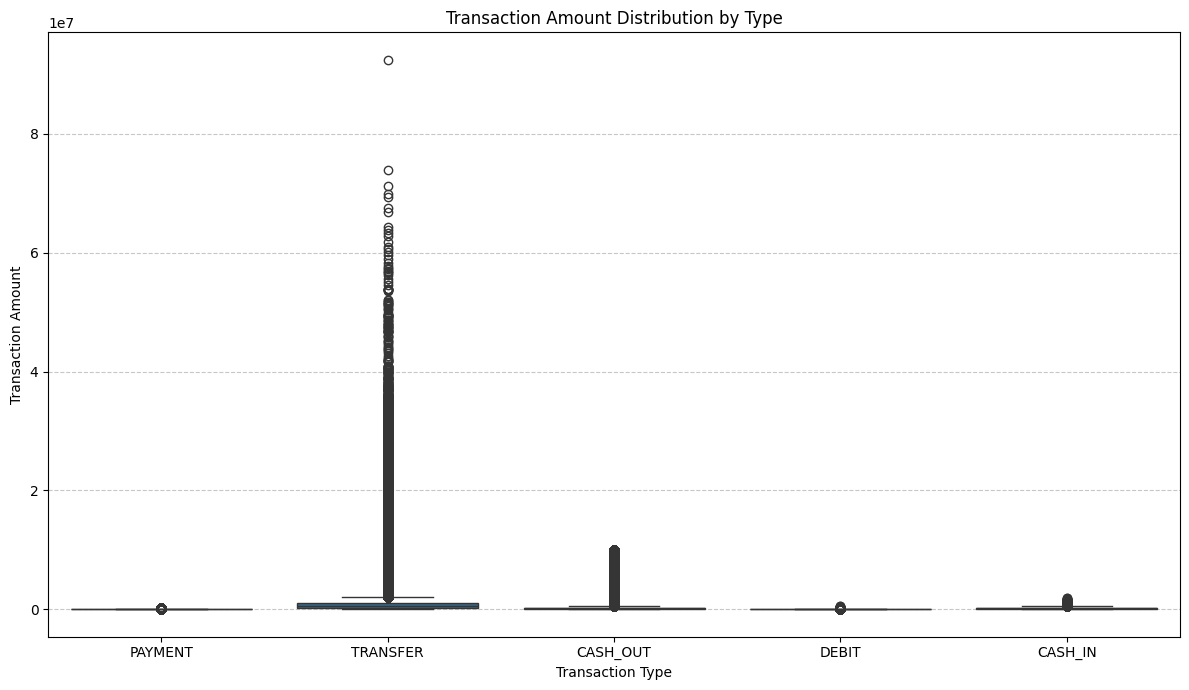

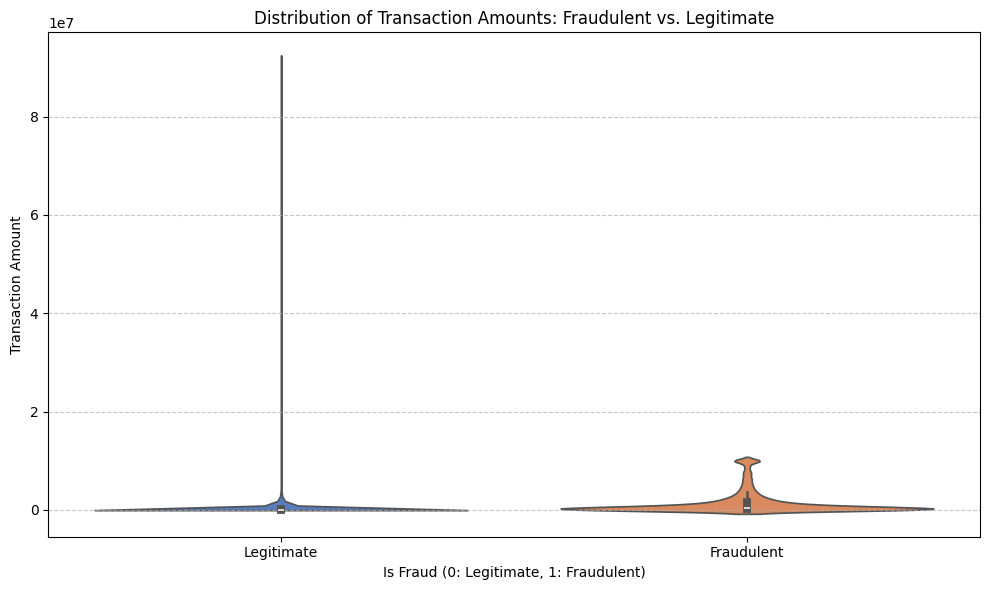

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 6. Create a box plot of the 'amount' column, grouped by the 'type' column
plt.figure(figsize=(12, 7))
sns.boxplot(x='type', y='amount', data=df, hue='type', palette='viridis', legend=False)
plt.title('Transaction Amount Distribution by Type')
plt.xlabel('Transaction Type')
plt.ylabel('Transaction Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 7. Create a violin plot to visualize the distribution of 'amount' split by 'isFraud'
plt.figure(figsize=(10, 6))
sns.violinplot(x='isFraud', y='amount', data=df, hue='isFraud', palette='muted', legend=False)
plt.title('Distribution of Transaction Amounts: Fraudulent vs. Legitimate')
plt.xlabel('Is Fraud (0: Legitimate, 1: Fraudulent)')
plt.ylabel('Transaction Amount')
plt.xticks(ticks=[0, 1], labels=['Legitimate', 'Fraudulent'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Temporal Analysis

### Subtask:
Plot the frequency of fraudulent transactions over 'step' (time steps) using a line chart. Create a heatmap showing peak fraud hours by mapping 'step' to hours of the day (step % 24). Calculate and plot the rolling fraud rate over time to identify trends. Ensure all plots have appropriate titles and legends.


#### Reasoning:
I will first filter the DataFrame to include only fraudulent transactions. Then, I will count the occurrences of these fraudulent transactions for each 'step' value and create a line plot to visualize the frequency of fraud over time. I will ensure the plot has a clear title and appropriately labeled axes.

**Reasoning**:
Following the reasoning provided, I will now write the Python code to filter fraudulent transactions, count them by 'step', and plot the frequency as a line chart to visualize fraud over time.



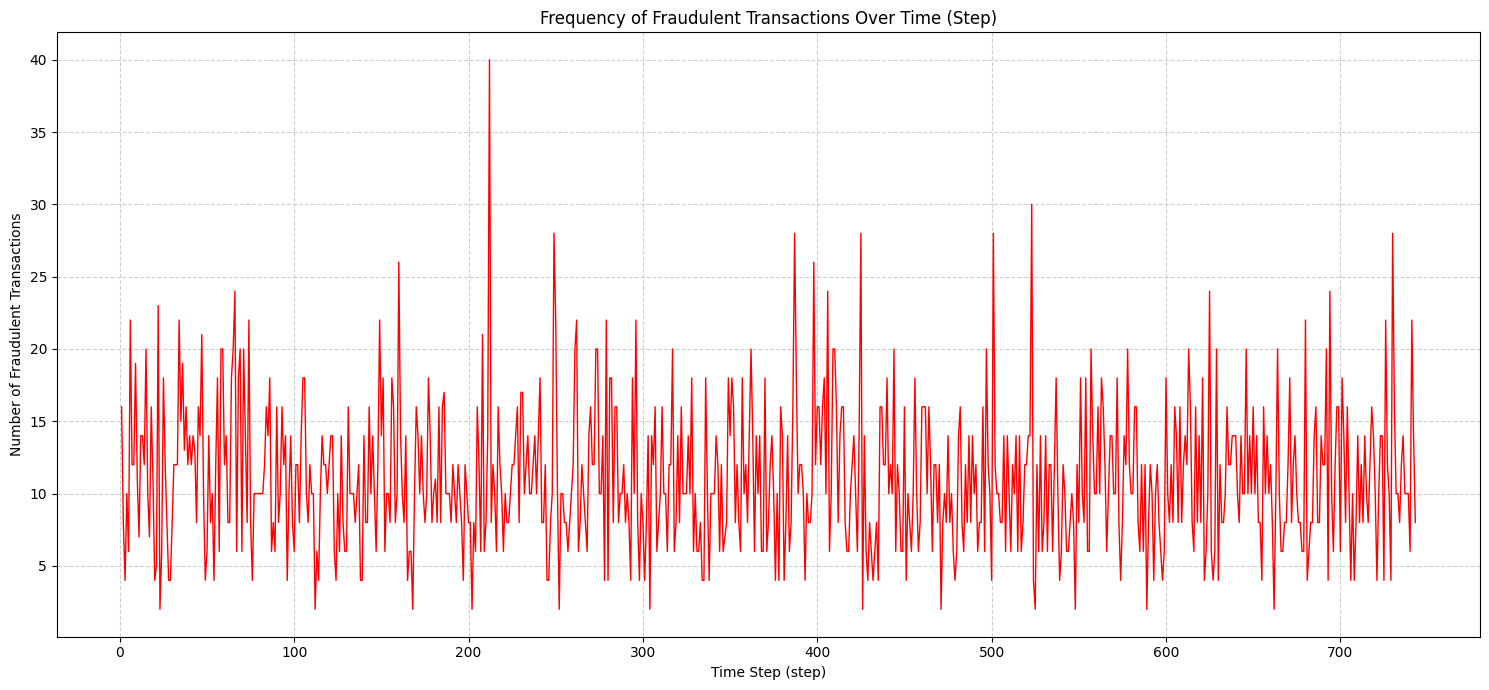

In [14]:
import matplotlib.pyplot as plt

# 1. Filter the DataFrame to include only fraudulent transactions
df_fraudulent = df[df['isFraud'] == 1]

# 2. Count the occurrences of fraudulent transactions for each 'step' value
fraud_frequency_by_step = df_fraudulent['step'].value_counts().sort_index()

# Create a line plot to visualize the frequency of fraud over time
plt.figure(figsize=(15, 7))
plt.plot(fraud_frequency_by_step.index, fraud_frequency_by_step.values, color='red', linewidth=1)
plt.title('Frequency of Fraudulent Transactions Over Time (Step)')
plt.xlabel('Time Step (step)')
plt.ylabel('Number of Fraudulent Transactions')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Reasoning**:
Following the instructions, I will now create a new 'hour' column by calculating `df['step'] % 24`. Then, I will derive a 'day' column from 'step' and create a pivot table to count fraudulent transactions by 'hour' and 'day' to generate a heatmap showing peak fraud hours.



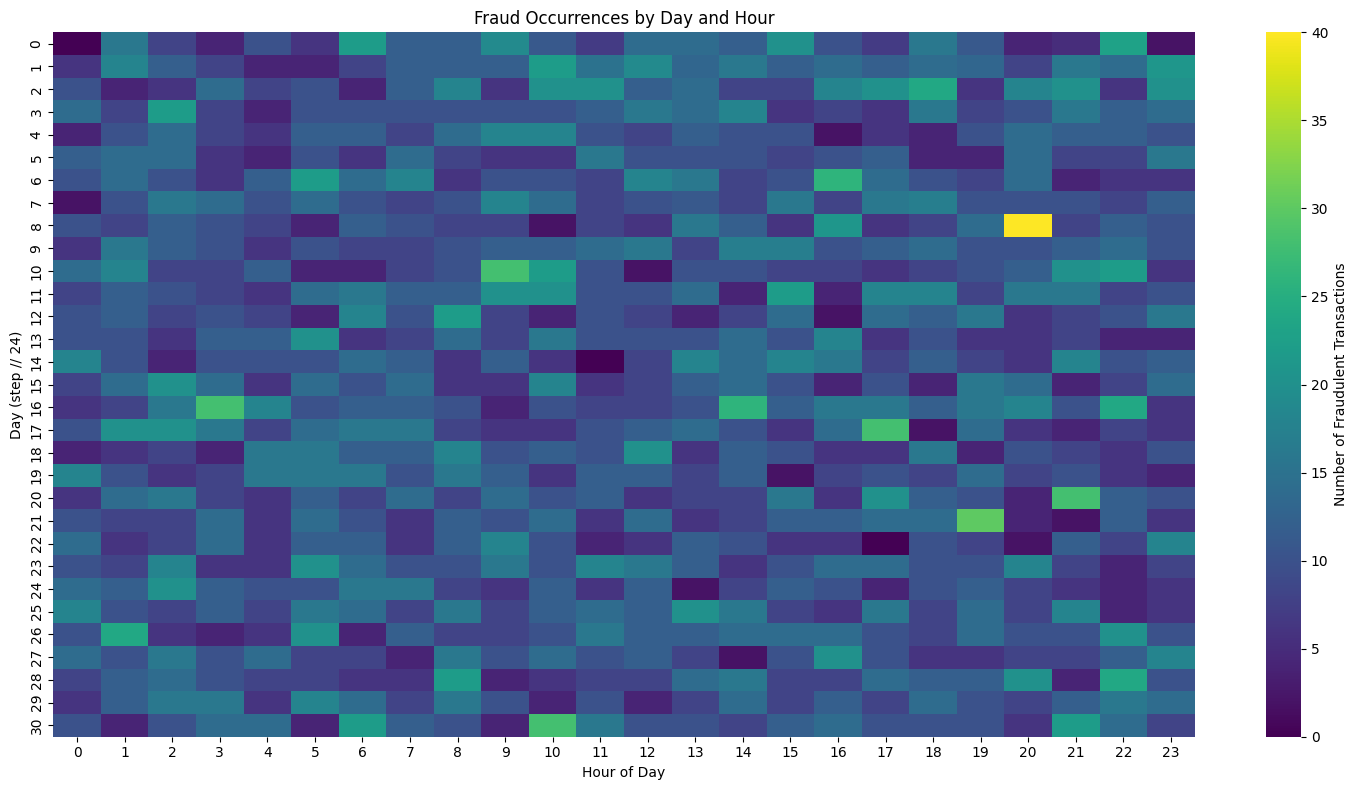

In [15]:
import seaborn as sns

# 3. Create a new column, 'hour', by calculating df['step'] % 24.
# Also create a 'day' column for better heatmap visualization
df_fraudulent = df[df['isFraud'] == 1].copy() # Work on a copy to avoid SettingWithCopyWarning
df_fraudulent['hour'] = df_fraudulent['step'] % 24
df_fraudulent['day'] = df_fraudulent['step'] // 24

# 4. Create a pivot table to count fraudulent transactions by 'hour' and 'day'
frequencies = df_fraudulent.groupby(['day', 'hour']).size().unstack(fill_value=0)

# Create a heatmap of fraud occurrences by 'hour' and 'day'
plt.figure(figsize=(15, 8))
sns.heatmap(frequencies, cmap='viridis', cbar_kws={'label': 'Number of Fraudulent Transactions'})
plt.title('Fraud Occurrences by Day and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day (step // 24)')
plt.tight_layout()
plt.show()

**Reasoning**:
Now, I will calculate the rolling average of the 'isFraud' column over a 24-step window to identify trends in the fraud rate over time and plot it as a line chart, completing the temporal analysis subtask.



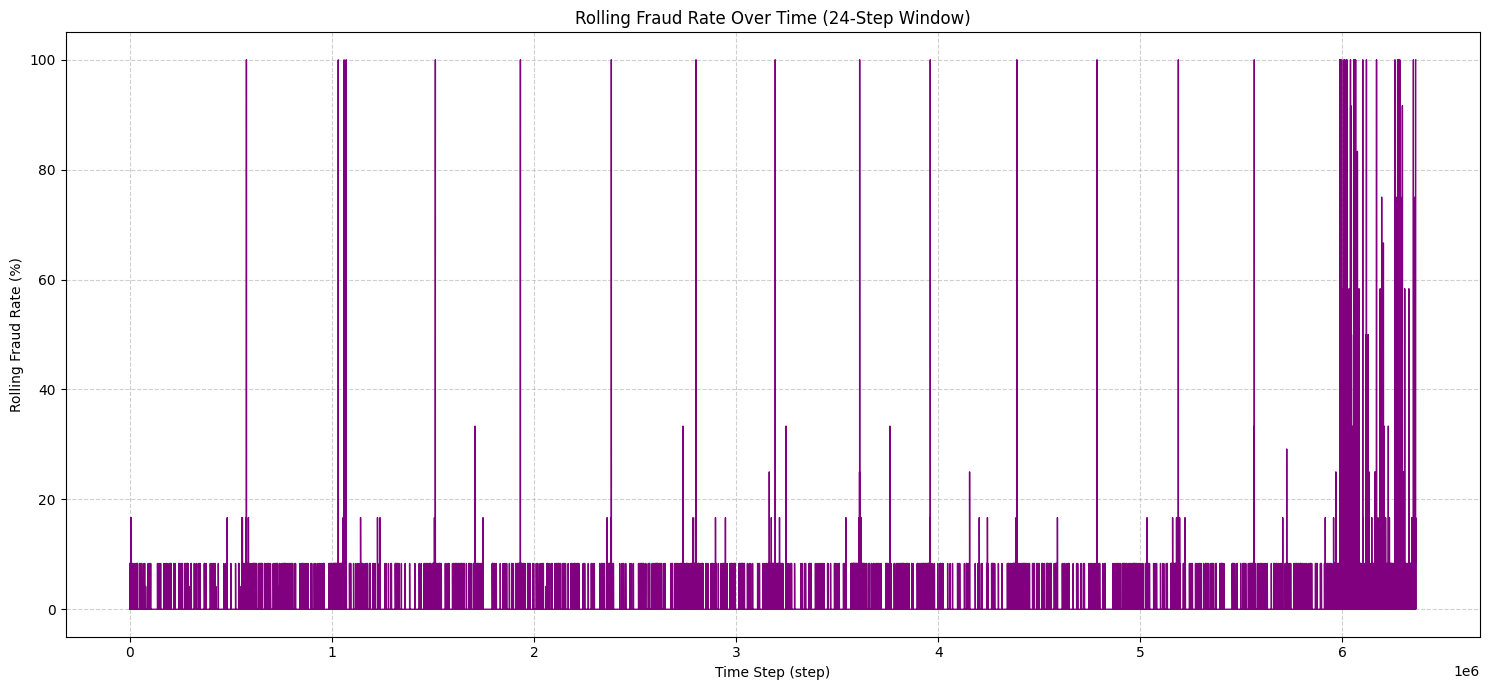

In [16]:
import matplotlib.pyplot as plt

# 5. Calculate the rolling average of the 'isFraud' column over a suitable window
# Using a window of 24 steps to represent a 'day' for rolling fraud rate
rolling_fraud_rate = df['isFraud'].rolling(window=24).mean() * 100

# Plot the rolling fraud rate as a line chart
plt.figure(figsize=(15, 7))
plt.plot(rolling_fraud_rate.index, rolling_fraud_rate.values, color='purple', linewidth=1)
plt.title('Rolling Fraud Rate Over Time (24-Step Window)')
plt.xlabel('Time Step (step)')
plt.ylabel('Rolling Fraud Rate (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Account Behavior Analysis

### Subtask:
Identify and list the top 20 accounts ('nameOrig') by transaction volume. Find and display accounts that appear as 'nameOrig' in multiple fraudulent transactions (repeat offenders). Analyze transactions where 'newbalanceOrig' becomes 0 after a transfer or cash out, indicating potential balance anomalies.


#### Reasoning:
To perform the account behavior analysis, I will follow these steps:
1.  **Calculate the total transaction amount for each unique 'nameOrig' account.** I will group the DataFrame by 'nameOrig', sum the 'amount' column, sort in descending order, and then display the top 20 accounts.
2.  **Identify repeat offenders in fraudulent transactions.** I will filter the DataFrame for fraudulent transactions, count 'nameOrig' occurrences, and display those appearing more than once.
3.  **Analyze balance anomalies after transfers/cash-outs.** I will filter for 'TRANSFER' and 'CASH_OUT' transactions where 'newbalanceOrig' is 0, and then display relevant columns to investigate these cases.

**Reasoning**:
I will calculate the total transaction amount for each unique 'nameOrig' account, sort them in descending order, and then display the top 20 accounts as per the first instruction of the subtask.



In [17]:
import pandas as pd

# 1. Calculate the total transaction amount for each unique 'nameOrig' account
top_20_accounts_by_volume = df.groupby('nameOrig')['amount'].sum().nlargest(20)

# Display the top 20 accounts by transaction volume
print("Top 20 accounts ('nameOrig') by transaction volume:\n")
print(top_20_accounts_by_volume)

Top 20 accounts ('nameOrig') by transaction volume:

nameOrig
C1715283297    92445516.64
C2127282686    73823490.36
C2044643633    71172480.42
C1425667947    69886731.30
C1584456031    69337316.27
C811810230     67500761.29
C420748282     66761272.21
C1139847449    64234448.19
C300140823     63847992.58
C372535854     63294839.63
C1539737626    62785416.91
C915403211     61733761.65
C453740720     60965275.64
C68968235      60642003.00
C31593462      60154456.05
C1273768806    59579503.33
C24299338      58944752.64
C1423766399    58318373.20
C208486812     57787800.93
C1139460122    57436619.46
Name: amount, dtype: float64


**Reasoning**:
I have completed the first instruction of the subtask by displaying the top 20 accounts by transaction volume. Now, I will proceed to the second instruction: filter the DataFrame for fraudulent transactions, count the occurrences of each 'nameOrig' account, and then display the 'nameOrig' accounts that appear in more than one fraudulent transaction (repeat offenders).



In [18]:
import pandas as pd

# 2. Filter the DataFrame to include only fraudulent transactions
df_fraudulent = df[df['isFraud'] == 1]

# Count the occurrences of each 'nameOrig' account in fraudulent transactions
fraud_originators_counts = df_fraudulent['nameOrig'].value_counts()

# Display 'nameOrig' accounts that appear in more than one fraudulent transaction
repeat_fraud_originators = fraud_originators_counts[fraud_originators_counts > 1]

print("\n'nameOrig' accounts appearing in multiple fraudulent transactions (repeat offenders):\n")
if not repeat_fraud_originators.empty:
    print(repeat_fraud_originators)
else:
    print("No 'nameOrig' accounts found with multiple fraudulent transactions.")


'nameOrig' accounts appearing in multiple fraudulent transactions (repeat offenders):

No 'nameOrig' accounts found with multiple fraudulent transactions.


**Reasoning**:
I have completed the first two instructions of the subtask. Now, I will proceed to the third instruction: filter the original DataFrame for 'TRANSFER' or 'CASH_OUT' transactions where 'newbalanceOrig' is 0, and then display relevant columns to investigate these potential balance anomalies.



In [19]:
import pandas as pd

# 3. Filter for 'TRANSFER' and 'CASH_OUT' transactions where 'newbalanceOrig' is 0
balance_anomaly_transactions = df[
    ((df['type'] == 'TRANSFER') | (df['type'] == 'CASH_OUT')) &
    (df['newbalanceOrig'] == 0)
]

print(
    "\nTransactions with 'newbalanceOrig' becoming 0 after TRANSFER or CASH_OUT (potential anomalies):\n"
)

# Display the first few rows of these transactions with relevant columns
if not balance_anomaly_transactions.empty:
    print(
        balance_anomaly_transactions[
            ['nameOrig', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'isFraud', 'type']
        ].head()
    )
else:
    print("No transactions found where 'newbalanceOrig' becomes 0 after TRANSFER or CASH_OUT.")


Transactions with 'newbalanceOrig' becoming 0 after TRANSFER or CASH_OUT (potential anomalies):

       nameOrig     amount  oldbalanceOrg  newbalanceOrig  isFraud      type
2   C1305486145     181.00          181.0             0.0        1  TRANSFER
3    C840083671     181.00          181.0             0.0        1  CASH_OUT
15   C905080434  229133.94        15325.0             0.0        0  CASH_OUT
19  C1670993182  215310.30          705.0             0.0        0  TRANSFER
24  C1984094095  311685.89        10835.0             0.0        0  TRANSFER


## Correlation and Feature Analysis

### Subtask:
Generate a correlation heatmap for all numerical features in the dataset. Plot the distributions of key numerical features, split by the 'isFraud' column. Analyze balance delta features by comparing '(oldbalanceOrg - newbalanceOrig)' with 'amount'.


**Reasoning**:
To begin the Correlation and Feature Analysis subtask, I will first select all numerical columns from the DataFrame `df`, calculate their pairwise correlation, and then generate a heatmap to visualize these correlations as per the instructions.



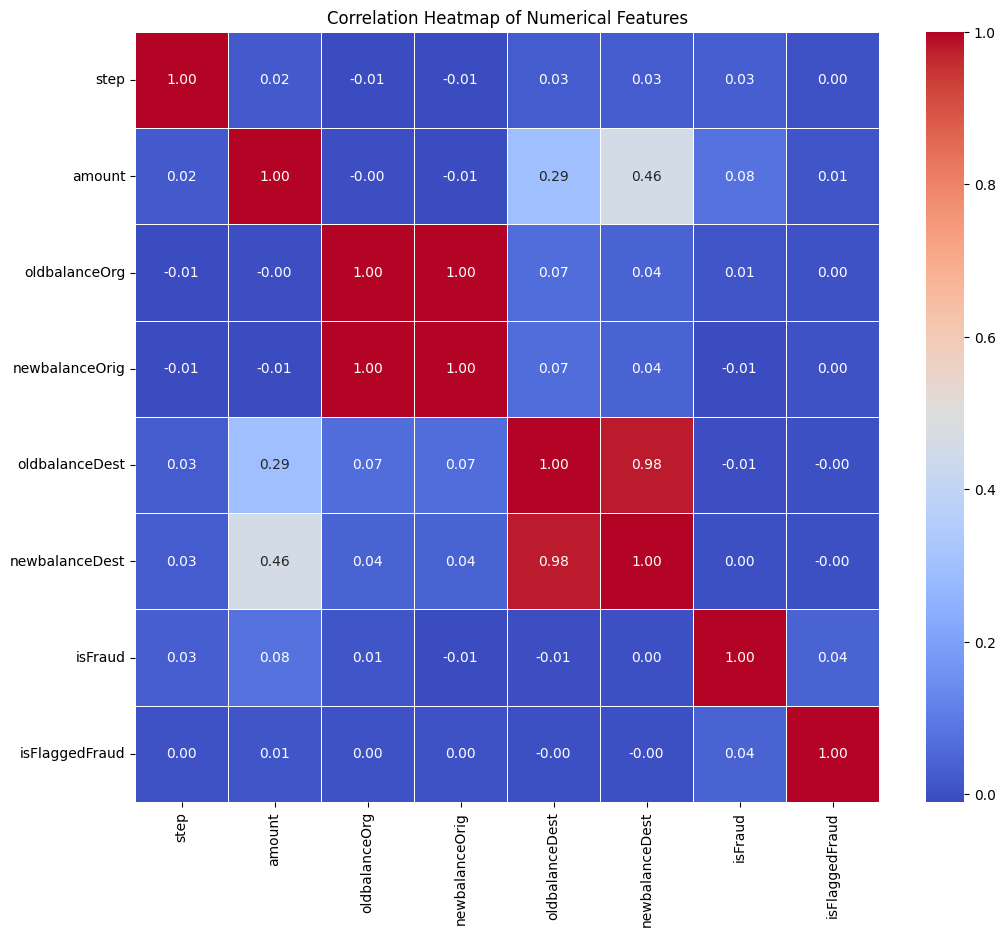

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select all numerical columns from the DataFrame `df`
numerical_cols = df.select_dtypes(include=['number']).columns

# Calculate their pairwise correlation
correlation_matrix = df[numerical_cols].corr()

# 2. Create a heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

**Reasoning**:
Now I will identify key numerical features and create kernel density estimate (KDE) plots for each, splitting the distributions by the 'isFraud' column to compare legitimate and fraudulent transaction patterns as per the subtask instructions.



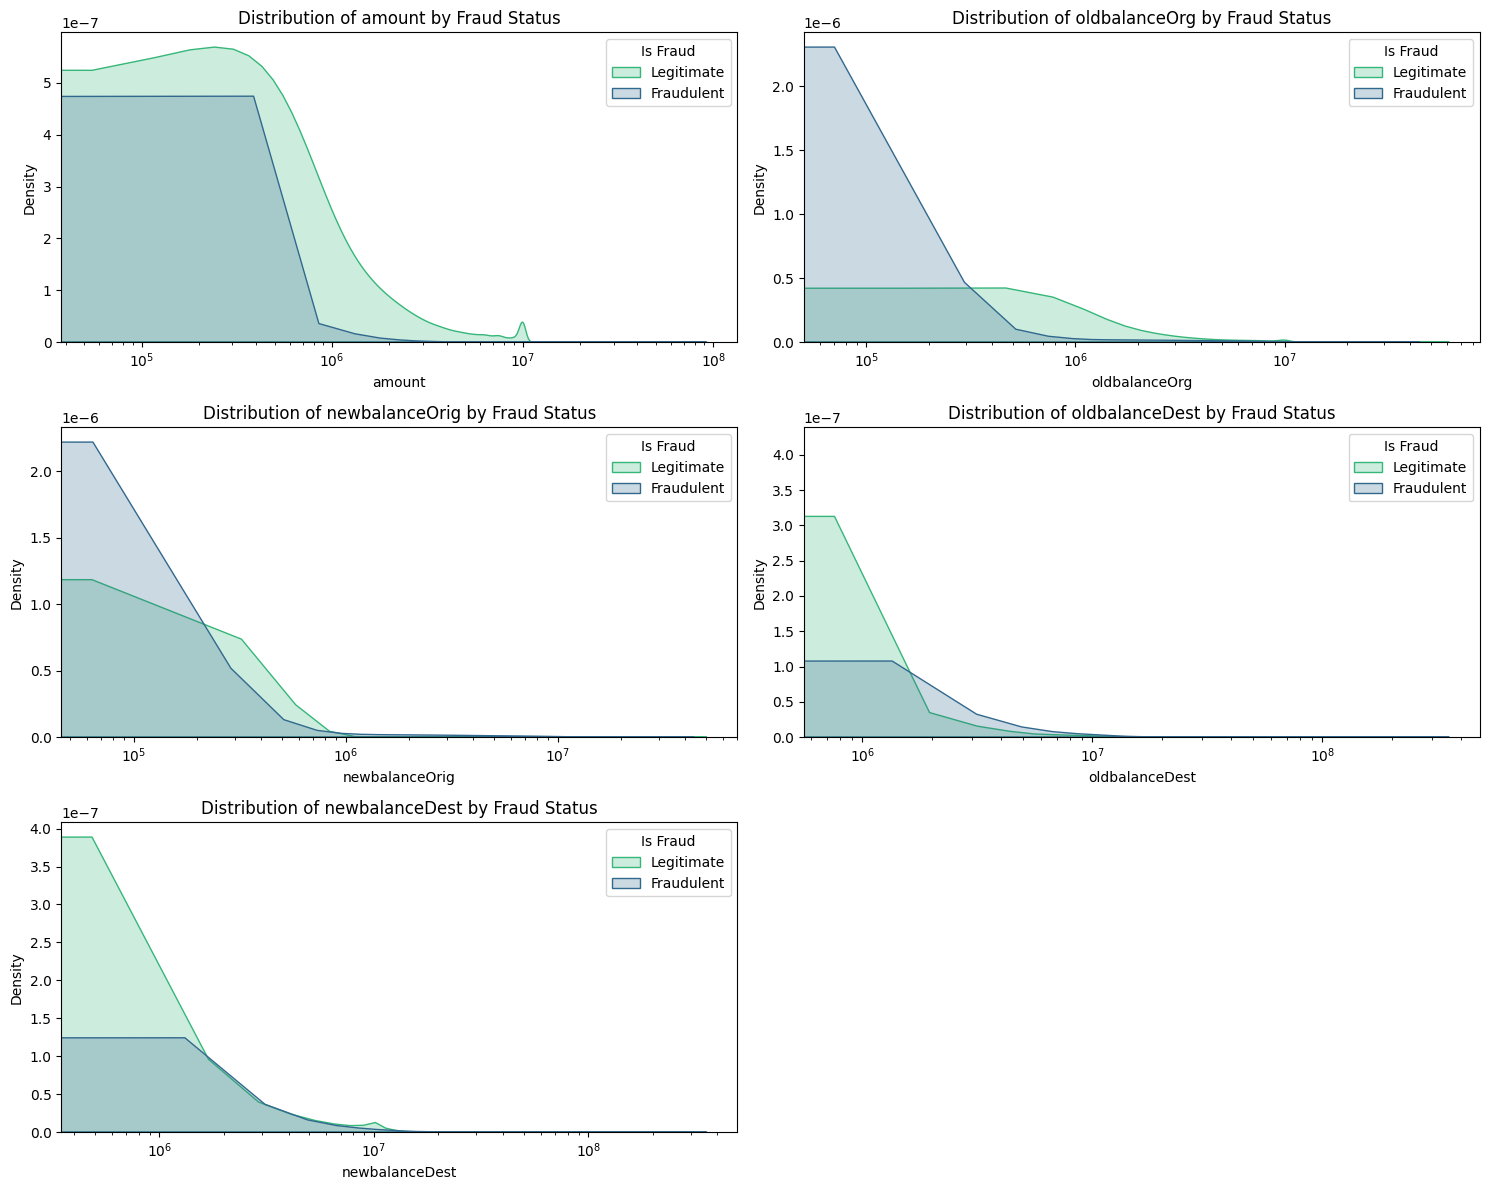

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Identify key numerical features for distribution analysis
key_numerical_features = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
]

# 4. For each identified key numerical feature, create a kernel density estimate (KDE) plot
plt.figure(figsize=(15, 12))
for i, feature in enumerate(key_numerical_features):
    plt.subplot(3, 2, i + 1)  # Arrange plots in a 3x2 grid
    sns.kdeplot(data=df, x=feature, hue='isFraud', fill=True, common_norm=False, palette='viridis')
    plt.title(f'Distribution of {feature} by Fraud Status')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.legend(title='Is Fraud', labels=['Legitimate', 'Fraudulent'])
    plt.xscale('log') # Use log scale for better visualization of skewed distributions

plt.tight_layout()
plt.show()


**Reasoning**:
Now, I will create two new columns, `balance_change_orig` and `balance_error_orig`, to analyze the balance delta features as instructed. `balance_change_orig` will represent the difference between `oldbalanceOrg` and `newbalanceOrig`, and `balance_error_orig` will show the discrepancy between this change and the `amount`.



In [22]:
import numpy as np

# 5. Create a new column named `balance_change_orig`
df['balance_change_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']

# 6. Create another new column named `balance_error_orig`
df['balance_error_orig'] = df['balance_change_orig'] - df['amount']

print("New columns 'balance_change_orig' and 'balance_error_orig' created.")
print(df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'balance_change_orig', 'balance_error_orig']].head())

New columns 'balance_change_orig' and 'balance_error_orig' created.
     amount  oldbalanceOrg  newbalanceOrig  balance_change_orig  \
0   9839.64       170136.0       160296.36              9839.64   
1   1864.28        21249.0        19384.72              1864.28   
2    181.00          181.0            0.00               181.00   
3    181.00          181.0            0.00               181.00   
4  11668.14        41554.0        29885.86             11668.14   

   balance_error_orig  
0        1.455192e-11  
1       -1.136868e-12  
2        0.000000e+00  
3        0.000000e+00  
4        0.000000e+00  


**Reasoning**:
I will filter the DataFrame to include only 'TRANSFER' and 'CASH_OUT' transactions where the `balance_error_orig` is not approximately zero, using a small epsilon to account for floating-point inaccuracies, and then display relevant columns to identify potential anomalies.



In [23]:
import numpy as np

# Define a small epsilon for floating point comparison
epsilon = 0.001

# 7. Filter the DataFrame to include only 'TRANSFER' and 'CASH_OUT' transactions
#    where the `balance_error_orig` is not approximately zero.
balance_anomaly_transactions_detailed = df[
    ((df['type'] == 'TRANSFER') | (df['type'] == 'CASH_OUT')) &
    (np.abs(df['balance_error_orig']) > epsilon)
]

print(
    "\nTransactions (TRANSFER/CASH_OUT) with significant 'balance_error_orig' (potential anomalies):\n"
)

# 8. Analyze the filtered transactions, noting any patterns or significant discrepancies,
#    especially in relation to the `isFraud` column.
#    Print the head of this filtered DataFrame with relevant columns.
if not balance_anomaly_transactions_detailed.empty:
    print(
        balance_anomaly_transactions_detailed[
            ['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'balance_change_orig', 'balance_error_orig', 'isFraud']
        ].head(10) # Displaying top 10 rows for better overview
    )
else:
    print("No TRANSFER or CASH_OUT transactions found with significant 'balance_error_orig'.")


Transactions (TRANSFER/CASH_OUT) with significant 'balance_error_orig' (potential anomalies):

        type     amount  oldbalanceOrg  newbalanceOrig  balance_change_orig  \
15  CASH_OUT  229133.94       15325.00            0.00             15325.00   
19  TRANSFER  215310.30         705.00            0.00               705.00   
24  TRANSFER  311685.89       10835.00            0.00             10835.00   
42  CASH_OUT  110414.71       26845.41            0.00             26845.41   
47  CASH_OUT   56953.90        1942.02            0.00              1942.02   
48  CASH_OUT    5346.89           0.00            0.00                 0.00   
51  CASH_OUT   23261.30       20411.53            0.00             20411.53   
60  CASH_OUT   82940.31        3017.87            0.00              3017.87   
71  CASH_OUT  136872.92      162075.98        25203.05            136872.93   
72  CASH_OUT   94253.33       25203.05            0.00             25203.05   

    balance_error_orig  isFraud  


## Missing Values and Data Quality

### Subtask:
Check for and display the count of null values for each column. Analyze destination accounts ('nameDest') that have a zero balance before and after transactions. Compare the 'isFlaggedFraud' column with 'isFraud' to identify any mismatches or discrepancies in the naive fraud flagging.


**Reasoning**:
I will calculate and print the sum of null values for each column in the DataFrame `df` to check for missing values, as per the first instruction of the subtask.



In [24]:
print("Sum of null values for each column:")
print(df.isnull().sum())

Sum of null values for each column:
step                   0
type                   0
amount                 0
nameOrig               0
oldbalanceOrg          0
newbalanceOrig         0
nameDest               0
oldbalanceDest         0
newbalanceDest         0
isFraud                0
isFlaggedFraud         0
balance_change_orig    0
balance_error_orig     0
dtype: int64


**Reasoning**:
I will now filter the DataFrame to identify transactions where both 'oldbalanceDest' and 'newbalanceDest' are zero, then display the count and a sample of relevant columns as per the second instruction of the subtask.



In [25]:
import pandas as pd

# 2. Filter the DataFrame to find transactions where 'oldbalanceDest' and 'newbalanceDest' are both zero
zero_balance_dest_transactions = df[
    (df['oldbalanceDest'] == 0) & (df['newbalanceDest'] == 0)
]

print(
    "\nTransactions where 'oldbalanceDest' and 'newbalanceDest' are both zero:\n"
)
print(
    f"Count of such transactions: {len(zero_balance_dest_transactions)}"
)

# Display a sample of relevant columns for these transactions
if not zero_balance_dest_transactions.empty:
    print("Sample of these transactions (first 5 rows):\n")
    print(
        zero_balance_dest_transactions[
            ['nameDest', 'amount', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'type']
        ].head()
    )
else:
    print("No transactions found where both 'oldbalanceDest' and 'newbalanceDest' are zero.")


Transactions where 'oldbalanceDest' and 'newbalanceDest' are both zero:

Count of such transactions: 2317282
Sample of these transactions (first 5 rows):

      nameDest    amount  oldbalanceDest  newbalanceDest  isFraud      type
0  M1979787155   9839.64             0.0             0.0        0   PAYMENT
1  M2044282225   1864.28             0.0             0.0        0   PAYMENT
2   C553264065    181.00             0.0             0.0        1  TRANSFER
4  M1230701703  11668.14             0.0             0.0        0   PAYMENT
5   M573487274   7817.71             0.0             0.0        0   PAYMENT


**Reasoning**:
I will calculate the number of transactions where 'isFlaggedFraud' is 1 and 'isFraud' is 0, and separately where 'isFlaggedFraud' is 0 and 'isFraud' is 1, to identify discrepancies in fraud flagging as per the subtask instructions.



In [26]:
import pandas as pd

# 3. Calculate the number of transactions where 'isFlaggedFraud' is 1 but 'isFraud' is 0
mismatch_flagged_legit = df[(df['isFlaggedFraud'] == 1) & (df['isFraud'] == 0)]
count_mismatch_flagged_legit = len(mismatch_flagged_legit)

# 4. Calculate the number of transactions where 'isFlaggedFraud' is 0 but 'isFraud' is 1
mismatch_unflagged_fraud = df[(df['isFlaggedFraud'] == 0) & (df['isFraud'] == 1)]
count_mismatch_unflagged_fraud = len(mismatch_unflagged_fraud)

# 5. Print the counts of these two types of discrepancies
print(f"\nNumber of transactions where 'isFlaggedFraud' is 1 but 'isFraud' is 0 (legit transactions incorrectly flagged): {count_mismatch_flagged_legit}")
print(f"Number of transactions where 'isFlaggedFraud' is 0 but 'isFraud' is 1 (fraudulent transactions not flagged): {count_mismatch_unflagged_fraud}")


Number of transactions where 'isFlaggedFraud' is 1 but 'isFraud' is 0 (legit transactions incorrectly flagged): 0
Number of transactions where 'isFlaggedFraud' is 0 but 'isFraud' is 1 (fraudulent transactions not flagged): 8197


## Save Summary Statistics

### Subtask:
Collect and save relevant summary statistics, such as fraud counts, fraud rates, top accounts, and any other notable findings from the EDA, into a JSON file named 'data/processed/paysim/eda_summary.json'.


**Reasoning**:
I will create a dictionary to store all the relevant summary statistics and then save this dictionary to a JSON file, converting pandas Series to dictionaries as required, and finally print a confirmation message.



In [28]:
import json
import os

# 1. Create a dictionary to store the summary statistics
summary_stats = {
    "fraud_counts": fraud_counts.to_dict(),
    "fraud_percentages": fraud_percentages.to_dict(),
    "fraud_rate_by_type": fraud_rate_by_type.to_dict(),
    "top_20_accounts_by_volume": top_20_accounts_by_volume.to_dict(),
    "mismatch_flagged_legit": count_mismatch_flagged_legit,
    "mismatch_unflagged_fraud": count_mismatch_unflagged_fraud
}

# Define the output directory and filename
output_dir = '/content/drive/MyDrive/Fraud-detection/Data/processed'
output_filename = os.path.join(output_dir, 'eda_summary.json')

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# 3. Save the dictionary to a JSON file
with open(output_filename, 'w') as f:
    json.dump(summary_stats, f, indent=4)

# 4. Print a confirmation message
print(f"Summary statistics saved to '{output_filename}'")

Summary statistics saved to '/content/drive/MyDrive/Fraud-detection/Data/processed/eda_summary.json'
